# Voice-Based Cognitive Decline Pattern Detection
Proof-of-Concept Pipeline (MemoTag)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install dependencies
!pip install librosa transformers scikit-learn matplotlib seaborn pydub

In [3]:
!pip install SpeechRecognition


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 36.4 MB/s eta 0:00:00


In [4]:
# Imports
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import speech_recognition as sr
from sklearn.cluster import KMeans
from transformers import pipeline
from pydub import AudioSegment

## Step 1: Preprocessing and Transcription

In [5]:
def transcribe_audio(audio_path):
    recognizer = sr.Recognizer()
    with sr.AudioFile(audio_path) as source:
        audio = recognizer.record(source)
    try:
        return recognizer.recognize_google(audio)
    except sr.UnknownValueError:
        return ""
    except sr.RequestError as e:
        return f"API Error: {e}"

## Step 2: Feature Extraction

In [16]:
import librosa
import numpy as np
import re
import string

def extract_features(audio_path, transcript):
    y, sr = librosa.load(audio_path, sr=None)

    # === 1. Duration
    duration = librosa.get_duration(y=y, sr=sr)

    # === 2. Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # === 3. Pitch Features
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    mean_pitch = np.mean(pitches[pitches > 0])
    pitch_variability = np.std(pitches[pitches > 0])

    # === 4. Pauses
    intervals = librosa.effects.split(y, top_db=30)
    speech_segments = sum((end - start) for start, end in intervals) / sr
    silence_duration = duration - speech_segments
    pause_count = len(intervals) - 1  # gaps between speech parts

    # === 5. Transcript-based features ===
    transcript = transcript.lower()
    words = transcript.split()
    word_count = len(words)
    sentence_count = len(re.findall(r'[.!?]', transcript)) or 1
    hesitation_words = ['uh', 'um', 'er', 'ah', 'eh']
    hesitation_count = sum(transcript.count(hw) for hw in hesitation_words)

    # === 6. Pauses per sentence
    pauses_per_sentence = pause_count / sentence_count

    # === 7. Hesitations
    hesitations = hesitation_count

    # === 8. Word Recall Issues (very basic check)
    common_subs = ['thing', 'stuff', 'something', 'thingy', 'whatever']
    word_recall_issues = sum(transcript.count(w) for w in common_subs)

    # === 9. Naming & Word-Association Tasks
    generic_words = ['thing', 'object', 'place', 'person', 'stuff']
    naming_issues = sum(transcript.count(w) for w in generic_words)

    # === 10. Sentence Completion
    completed_sentences = re.findall(r'\b[^.?!]*[.?!]', transcript)
    percent_complete_sentences = len(completed_sentences) / sentence_count

    # === 11. Speech Rate
    speech_rate = word_count / duration if duration > 0 else 0

    return {
        'duration': duration,
        'tempo': tempo,
        'mean_pitch': float(mean_pitch),
        'pitch_variability': float(pitch_variability),
        'pauses': pause_count,
        'pauses_per_sentence': pauses_per_sentence,
        'hesitations': hesitations,
        'word_recall_issues': word_recall_issues,
        'naming_issues': naming_issues,
        'sentence_completion': round(percent_complete_sentences, 2),
        'speech_rate': speech_rate
    }


## Step 3: Load and Process Audio Files

In [17]:
audio_folder = "/content/drive/MyDrive/audio_samples"  # Replace with your folder path
feature_list = []
transcripts = {}

for file in os.listdir(audio_folder):
    if file.endswith(".wav") or file.endswith(".mp3"):
        path = os.path.join(audio_folder, file)
        transcript = transcribe_audio(path)
        print(f"Transcription for {file}:\n{transcript}\n{'-'*60}")
        transcripts[file] = transcript
        features = extract_features(path, transcript)
        features['file'] = file
        feature_list.append(features)

Transcription for harvard.wav:
does snail smell of old beer lingers it takes heat to bring out the odor a cold dip restores health and zest a salt pickle taste fine with ham tacos al pastor are my favorite a zestful food is the hot cross bun
------------------------------------------------------------
Transcription for genevieve.wav:
this Dynamic Workshop aims to provide up-to-date information on pharmacological approaches comma issues comma and treatment in the geriatric population to assist in preventing medication-related problems comma appropriately and effectively managing medications and compliance period the concept of polypharmacy parentheses taking multiple types of drugs parentheses will also be discussed comma as this is a common issue that can impact adverse side effects in the geriatric population period participants will leave with the knowledge and considerations of common drug interaction and how to minimize effects that limit function period Summit professional educati

## Step 4: Unsupervised ML - Clustering to detect anomalies

In [18]:
import pandas as pd

df = pd.DataFrame(feature_list)
X = df[['speech_rate', 'mean_pitch', 'hesitations', 'pauses']]
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
df['cluster'] = kmeans.labels_

df.sort_values(by='cluster')

,duration,tempo,mean_pitch,pitch_variability,pauses,pauses_per_sentence,hesitations,word_recall_issues,naming_issues,sentence_completion,speech_rate,file,cluster
0,18.356190,[107.666015625],1497.128662,1150.867676,42,42.0,2,0,0,0.0,2.342534,harvard.wav,0
1,70.334542,[122.28260869565217],1372.958252,1084.805298,126,126.0,16,0,0,0.0,1.734567,genevieve.wav,0
2,295.056009,[156.60511363636363],1632.732666,992.394104,360,360.0,2,0,0,0.0,0.152513,winston-churchill.wav,1


## Step 5: Visualization

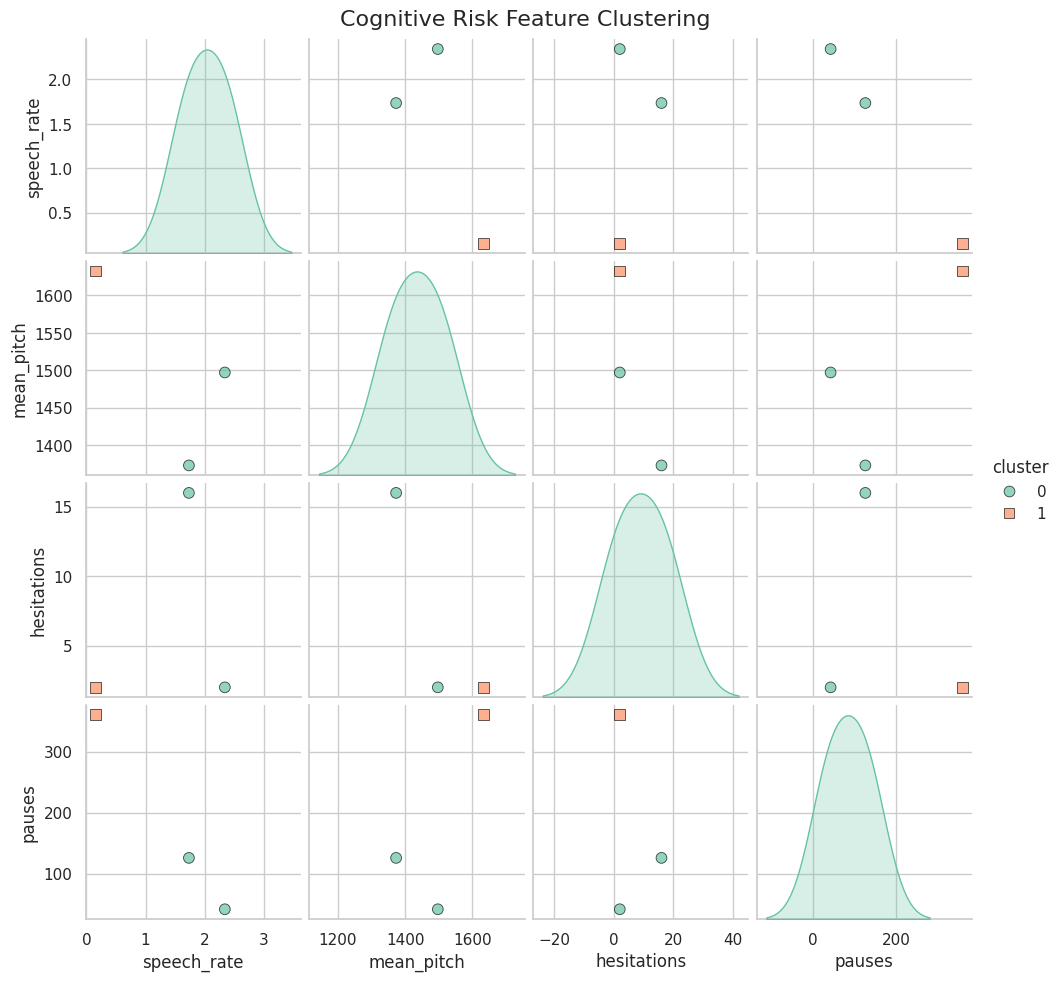

In [23]:
sns.set(style="whitegrid", palette="Set2")
import warnings

# Suppress specific warnings from Seaborn
warnings.filterwarnings("ignore", message="The markers list has more values.*")

# Enhanced pairplot
plot = sns.pairplot(
    df,
    hue="cluster",
    vars=['speech_rate', 'mean_pitch', 'hesitations', 'pauses'],
    markers=["o", "s", "D"],
    plot_kws={'alpha': 0.7, 's': 60, 'edgecolor': 'k'}
)

plot.fig.suptitle("Cognitive Risk Feature Clustering", fontsize=16)
plot.fig.subplots_adjust(top=0.95)  # adjust to fit title
plt.show()

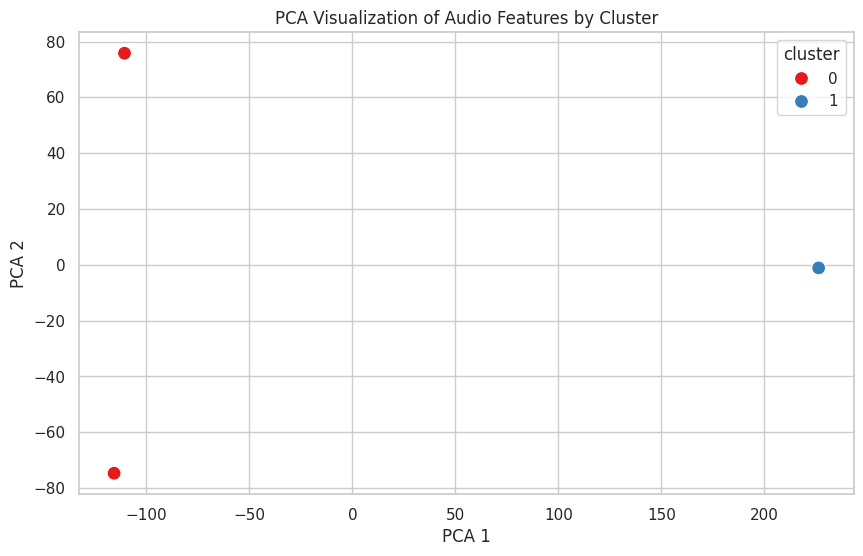

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df[['speech_rate', 'mean_pitch', 'hesitations', 'pauses']])
df['pca1'] = pca_components[:, 0]
df['pca2'] = pca_components[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', s=100, palette='Set1')
plt.title("PCA Visualization of Audio Features by Cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


In [21]:
import os
import warnings
from sklearn.utils._tags import _safe_tags
from sklearn.utils.validation import _check_feature_names_in

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but KMeans was fitted with feature names"
)


def get_risk_score_from_audio(audio_path, cluster_model):
    # Transcribe the audio
    transcript = transcribe_audio(audio_path)

    # Extract features
    features = extract_features(audio_path, transcript)

    # Prepare feature vector for clustering
    feature_vector = [[
        features['speech_rate'],
        features['mean_pitch'],
        features['hesitations'],
        features['pauses']
    ]]

    # Predict cluster (risk score)
    risk_score = cluster_model.predict(feature_vector)[0]

    return {
        'file': os.path.basename(audio_path),
        'risk_score': int(risk_score),
        'transcript': transcript,
        'features': features
    }

# === Main loop to process all 3 audio files ===

audio_folder = "/content/drive/MyDrive/audio_samples"  # Replace with your actual path

all_results = []

for file in os.listdir(audio_folder):
    if file.endswith(".wav") or file.endswith(".mp3"):
        audio_path = os.path.join(audio_folder, file)
        result = get_risk_score_from_audio(audio_path, cluster_model=kmeans)
        all_results.append(result)

# === Print Results ===

for res in all_results:
    print(f"\n🗂️ File: {res['file']}")
    print(f"🧠 Risk Score (Cluster): {res['risk_score']}")
    print(f"📝 Transcript: {res['transcript']}")
    print(f"📊 Features: {res['features']}")



🗂️ File: harvard.wav
🧠 Risk Score (Cluster): 0
📝 Transcript: does snail smell of old beer lingers it takes heat to bring out the odor a cold dip restores health and zest a salt pickle taste fine with ham tacos al pastor are my favorite a zestful food is the hot cross bun
📊 Features: {'duration': 18.356190476190477, 'tempo': array([107.66601562]), 'mean_pitch': 1497.128662109375, 'pitch_variability': 1150.86767578125, 'pauses': 42, 'pauses_per_sentence': 42.0, 'hesitations': 2, 'word_recall_issues': 0, 'naming_issues': 0, 'sentence_completion': 0.0, 'speech_rate': 2.342533983604856}

🗂️ File: genevieve.wav
🧠 Risk Score (Cluster): 0
📝 Transcript: this Dynamic Workshop aims to provide up-to-date information on pharmacological approaches comma issues comma and treatment in the geriatric population to assist in preventing medication-related problems comma appropriately and effectively managing medications and compliance period the concept of polypharmacy parentheses taking multiple types o